# FinServe Bank Transactions - EDA

Cleaned this in Excel first, ran some checks in SQL, and this is the Python part - just exploring the data and pulling out the visuals before I write up findings.


In [ ]:
# usual imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,5)
pd.set_option('display.max_columns', None)

In [ ]:
# load the cleaned file
df = pd.read_excel('C:\FinServe_Bank_Transactions_clean.csv')
df.shape

(2141, 16)

In [3]:
# quick peek
df.head()

  TransactionID AccountID  TransactionAmount     TransactionDate  \
0      TX000503   AC00103             919.71 2023-09-28 17:53:00   
1      TX001483   AC00218             919.71 2023-03-31 16:34:00   
2      TX000467   AC00063             919.71 2023-11-20 16:27:00   
3      TX000798   AC00208             919.71 2023-12-29 17:17:00   
4      TX002029   AC00172             919.71 2023-01-05 16:18:00   

  TransactionType      Location DeviceID      IP Address MerchantID Channel  \
0           Debit       Raleigh  D000283   54.252.249.33       M014  ONLINE   
1           Debit    Sacramento  D000320   45.182.28.148       M067     ATM   
2           Debit        Fresno  D000039   185.23.87.107       M015     ATM   
3           Debit  Jacksonville  D000471  147.125.143.41       M075     ATM   
4           Debit       Atlanta  D000363  223.189.165.37       M021  ONLINE   

   CustomerAge CustomerOccupation  TransactionDuration  LoginAttempts  \
0           65            Retired          

In [4]:
# check dtypes and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2141 entries, 0 to 2140
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   TransactionID            2141 non-null   str           
 1   AccountID                2141 non-null   str           
 2   TransactionAmount        2141 non-null   float64       
 3   TransactionDate          2141 non-null   datetime64[us]
 4   TransactionType          2141 non-null   str           
 5   Location                 2141 non-null   str           
 6   DeviceID                 2141 non-null   str           
 7   IP Address               2141 non-null   str           
 8   MerchantID               2141 non-null   str           
 9   Channel                  2141 non-null   str           
 10  CustomerAge              2141 non-null   int64         
 11  CustomerOccupation       2141 non-null   str           
 12  TransactionDuration      2141 non-null   int6

In [5]:
# any missing values left after the excel cleanup
df.isnull().sum()

TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64

In [6]:
# checking for exact dupes and duplicate transaction ids
df.duplicated().sum(), df['TransactionID'].duplicated().sum()

(np.int64(1), np.int64(26))

In [7]:
# 26 ids show up twice, taking a look before deciding to drop
df[df['TransactionID'].duplicated(keep=False)].sort_values('TransactionID').head(10)

     TransactionID AccountID  TransactionAmount     TransactionDate  \
1456      TX000060   AC00427             112.07 2023-02-10 16:35:00   
1457      TX000060   AC00427             112.07 2023-02-10 16:35:00   
797       TX000132   AC00384             302.45 2023-09-25 17:13:00   
796       TX000132   AC00384             302.45 2023-09-25 17:13:00   
376       TX000148   AC00161             514.95 2023-04-13 00:00:00   
377       TX000148   AC00161             514.95 2023-04-13 00:00:00   
1327      TX000338   AC00439             138.95 2023-02-06 16:48:00   
1326      TX000338   AC00439             138.95 2023-02-06 16:48:00   
1424      TX000423   AC00333             119.11 2023-06-30 00:00:00   
1425      TX000423   AC00333             119.11 2023-06-30 00:00:00   

     TransactionType     Location DeviceID       IP Address MerchantID  \
1456           Debit  Kansas City  D000089  198.166.198.233       M064   
1457          Credit  Kansas City  D000089  198.166.198.233       M064

In [8]:
# pulling hour/day/month out of the timestamp, need these later
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['PreviousTransactionDate'] = pd.to_datetime(df['PreviousTransactionDate'])
df['Hour'] = df['TransactionDate'].dt.hour
df['DayOfWeek'] = df['TransactionDate'].dt.day_name()
df['Month'] = df['TransactionDate'].dt.to_period('M').astype(str)
df[['TransactionDate','Hour','DayOfWeek','Month']].head()

      TransactionDate  Hour DayOfWeek    Month
0 2023-09-28 17:53:00    17  Thursday  2023-09
1 2023-03-31 16:34:00    16    Friday  2023-03
2 2023-11-20 16:27:00    16    Monday  2023-11
3 2023-12-29 17:17:00    17    Friday  2023-12
4 2023-01-05 16:18:00    16  Thursday  2023-01

In [9]:
# standard describe to get a feel for scale/ranges
df.describe()

       TransactionAmount             TransactionDate  CustomerAge  \
count        2141.000000                        2141  2141.000000   
mean          286.057515  2023-07-03 06:25:52.965903    45.209715   
min             0.260000         2023-01-02 00:00:00    19.000000   
25%            81.110000         2023-03-28 00:00:00    28.000000   
50%           211.100000         2023-07-04 18:55:00    45.000000   
75%           416.550000         2023-10-05 18:49:00    59.000000   
max           919.710000         2024-01-01 17:37:00    80.000000   
std           253.892396                         NaN    17.079841   

       TransactionDuration  LoginAttempts  AccountBalance  \
count          2141.000000    2141.000000     2141.000000   
mean            119.411490       1.178888     5112.542027   
min              10.000000      -3.000000      101.250000   
25%              63.000000       1.000000     1514.340000   
50%             113.000000       1.000000     4736.725000   
75%         

## Categorical columns
type, channel, occupation, location - basically who's doing what and how


In [10]:
# how are debit/credit split
df['TransactionType'].value_counts()

TransactionType
Debit     1849
Credit     292
Name: count, dtype: int64

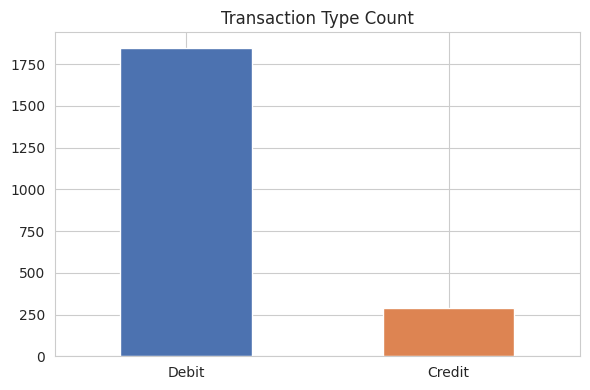

In [11]:

fig, ax = plt.subplots(figsize=(6,4))
df['TransactionType'].value_counts().plot(kind='bar', color=['#4C72B0','#DD8452'], ax=ax)
ax.set_title('Transaction Type Count')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
# atm/online/branch split
df['Channel'].value_counts()

Channel
BRANCH     730
ATM        713
ONLINE     683
Unknown     15
Name: count, dtype: int64

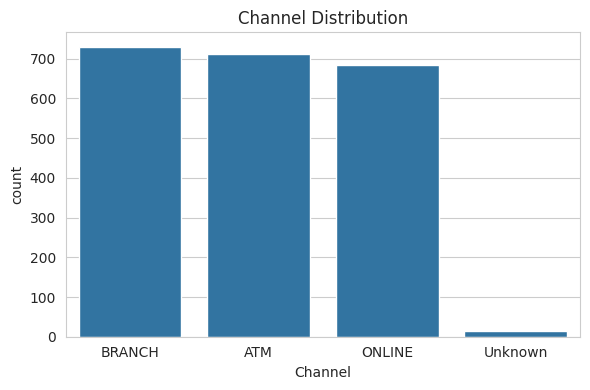

In [13]:

fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(x='Channel', data=df, order=df['Channel'].value_counts().index, ax=ax)
ax.set_title('Channel Distribution')
plt.tight_layout()
plt.show()

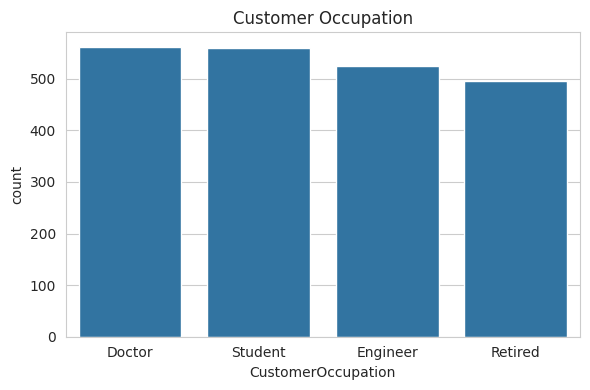

In [14]:
# occupation counts
fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(x='CustomerOccupation', data=df, order=df['CustomerOccupation'].value_counts().index, ax=ax)
ax.set_title('Customer Occupation')
plt.tight_layout()
plt.show()

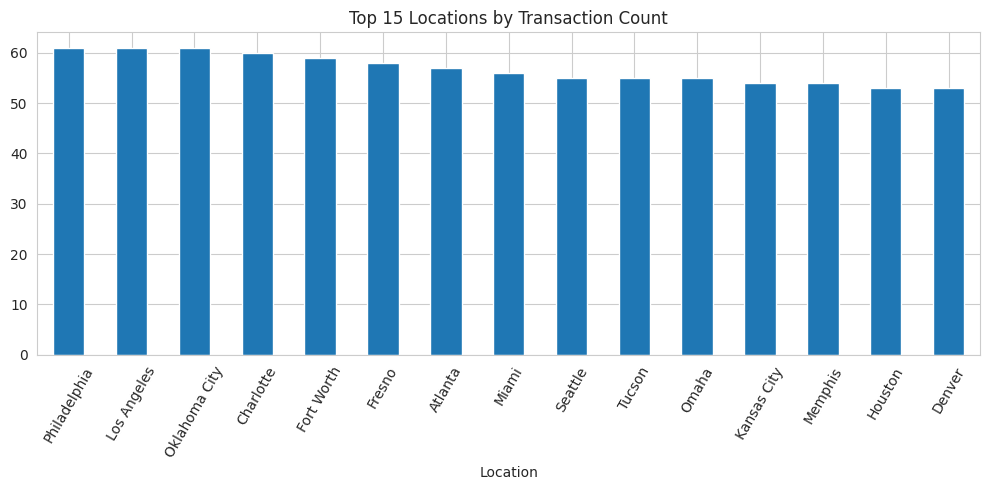

In [15]:
# top 15 locations, long tail after that so cutting it off
top_loc = df['Location'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10,5))
top_loc.plot(kind='bar', ax=ax)
ax.set_title('Top 15 Locations by Transaction Count')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

## Numeric distributions
amount, age, balance, duration, login attempts


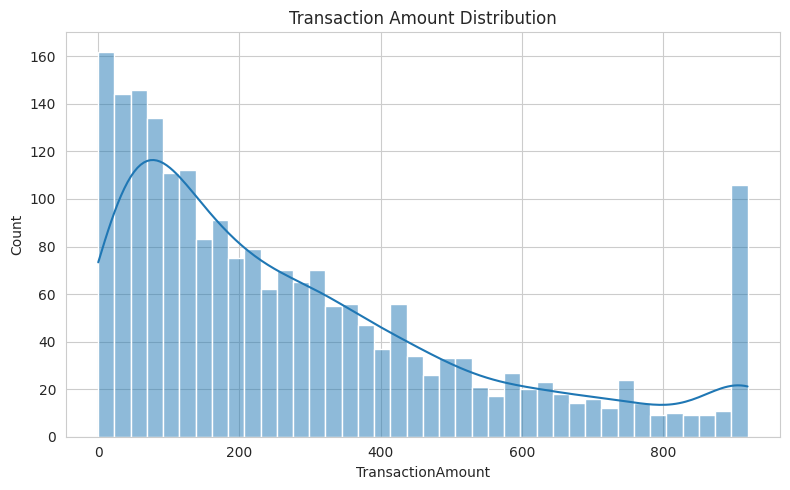

In [16]:
# amount is probably going to be skewed
fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(df['TransactionAmount'], bins=40, kde=True, ax=ax)
ax.set_title('Transaction Amount Distribution')
plt.tight_layout()
plt.show()

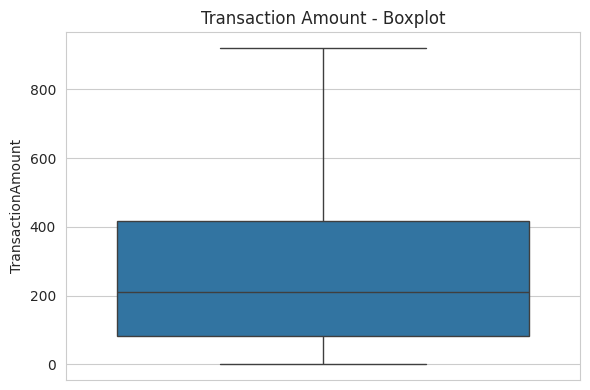

In [17]:
# boxplot to spot outliers on amount
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(y=df['TransactionAmount'], ax=ax)
ax.set_title('Transaction Amount - Boxplot')
plt.tight_layout()
plt.show()

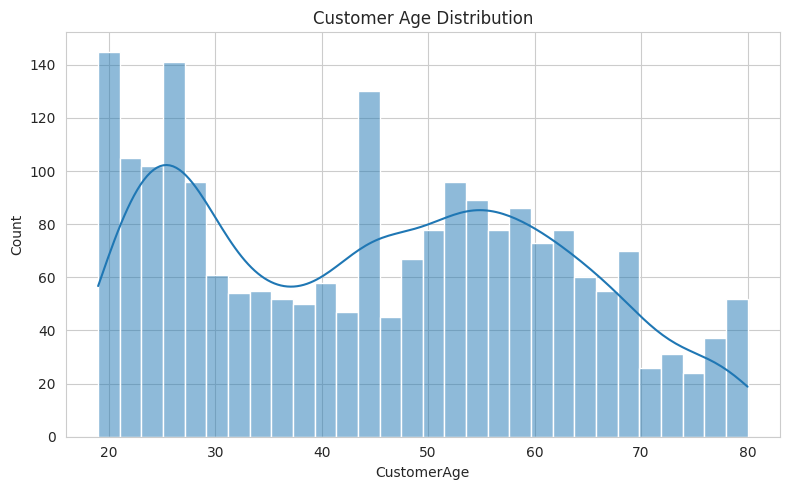

In [18]:

fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(df['CustomerAge'], bins=30, kde=True, ax=ax)
ax.set_title('Customer Age Distribution')
plt.tight_layout()
plt.show()

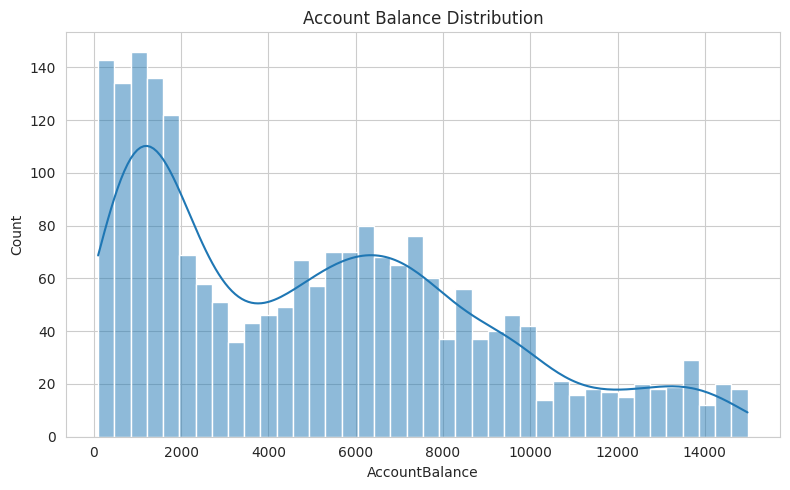

In [19]:

fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(df['AccountBalance'], bins=40, kde=True, ax=ax)
ax.set_title('Account Balance Distribution')
plt.tight_layout()
plt.show()

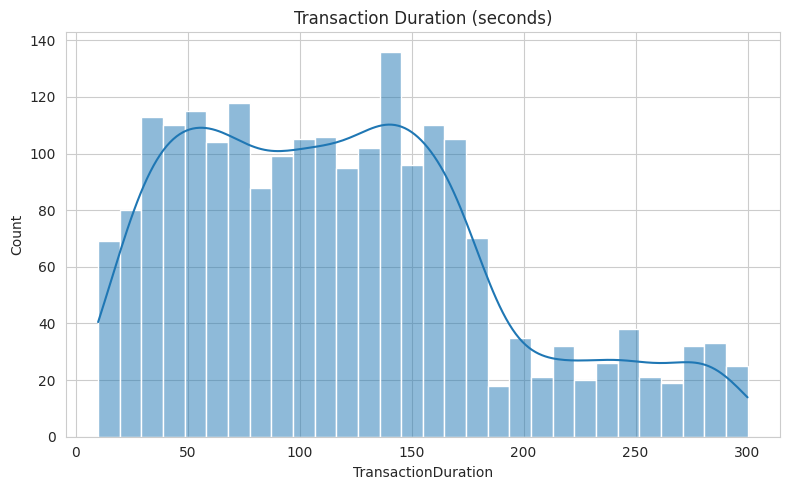

In [20]:

fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(df['TransactionDuration'], bins=30, kde=True, ax=ax)
ax.set_title('Transaction Duration (seconds)')
plt.tight_layout()
plt.show()

In [21]:
# most people log in fine on first try, curious how many don't
df['LoginAttempts'].value_counts().sort_index()

LoginAttempts
-3        1
 0        1
 1     2042
 2       22
 3       23
 4       27
 5       23
 50       1
 99       1
Name: count, dtype: int64

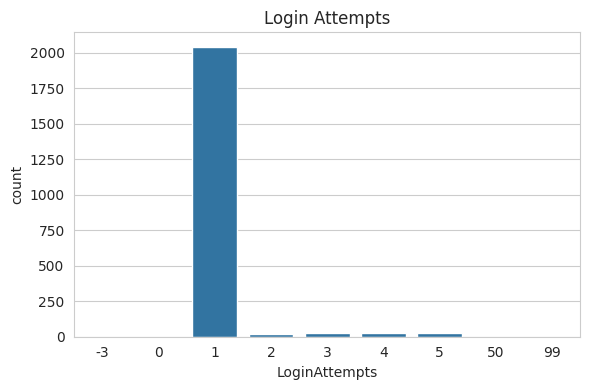

In [22]:

fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(x='LoginAttempts', data=df, ax=ax)
ax.set_title('Login Attempts')
plt.tight_layout()
plt.show()

## Amount vs categories
does spend change depending on type/channel/occupation


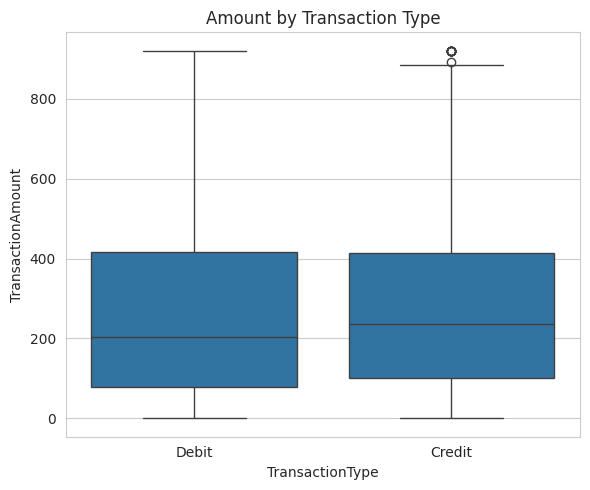

In [23]:

fig, ax = plt.subplots(figsize=(6,5))
sns.boxplot(x='TransactionType', y='TransactionAmount', data=df, ax=ax)
ax.set_title('Amount by Transaction Type')
plt.tight_layout()
plt.show()

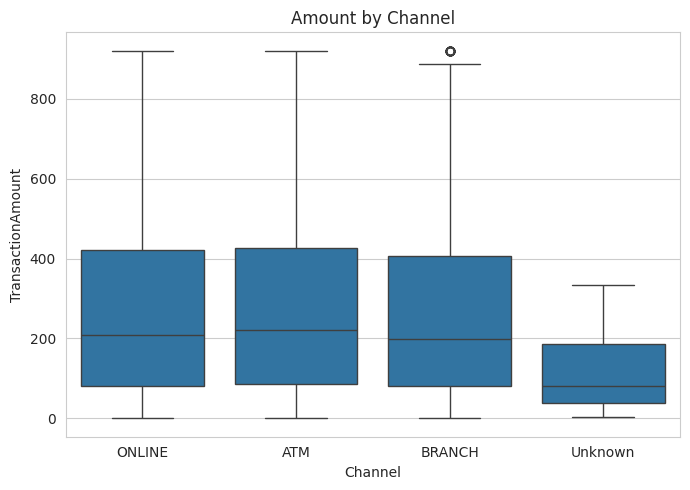

In [24]:

fig, ax = plt.subplots(figsize=(7,5))
sns.boxplot(x='Channel', y='TransactionAmount', data=df, ax=ax)
ax.set_title('Amount by Channel')
plt.tight_layout()
plt.show()

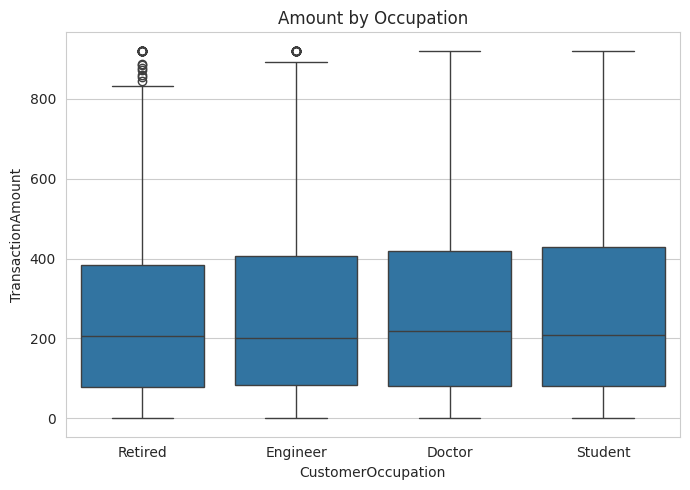

In [25]:

fig, ax = plt.subplots(figsize=(7,5))
sns.boxplot(x='CustomerOccupation', y='TransactionAmount', data=df, ax=ax)
ax.set_title('Amount by Occupation')
plt.tight_layout()
plt.show()

## Correlation
checking if any of the numeric fields move together before I read too much into anything


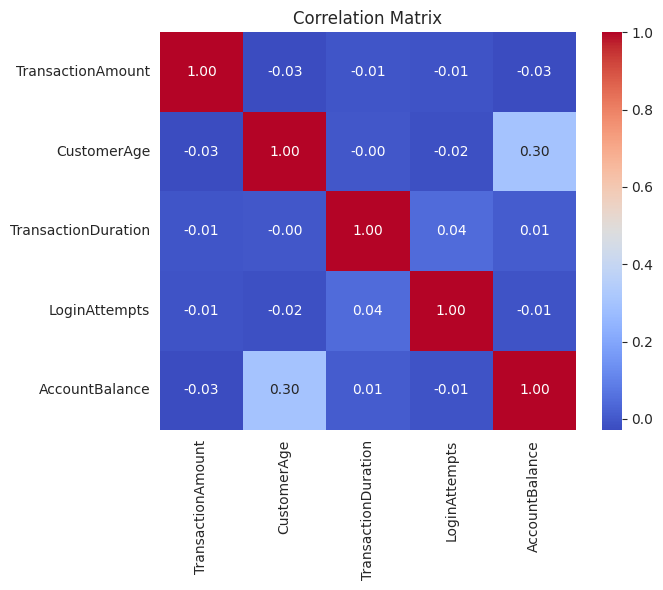

In [26]:

corr_cols = ['TransactionAmount','CustomerAge','TransactionDuration','LoginAttempts','AccountBalance']
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

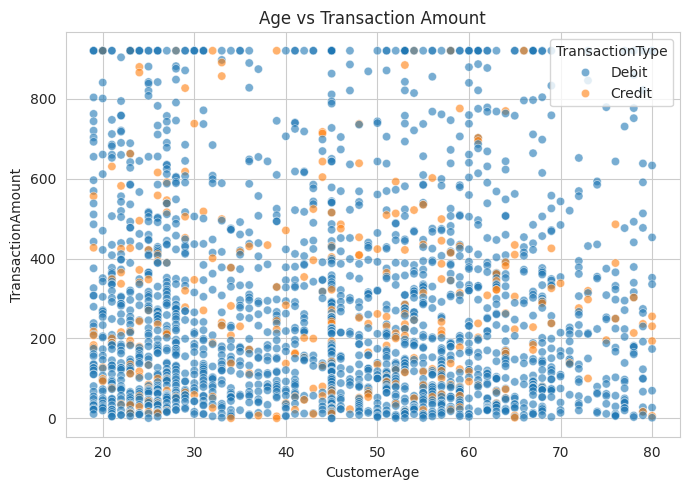

In [27]:

fig, ax = plt.subplots(figsize=(7,5))
sns.scatterplot(x='CustomerAge', y='TransactionAmount', hue='TransactionType', data=df, alpha=0.6, ax=ax)
ax.set_title('Age vs Transaction Amount')
plt.tight_layout()
plt.show()

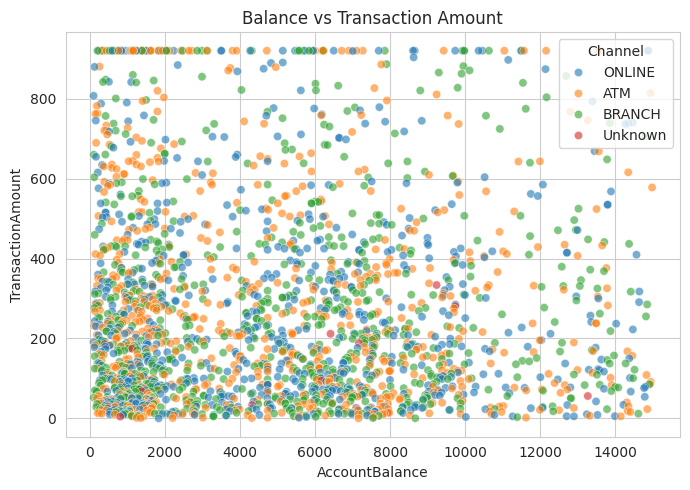

In [28]:

fig, ax = plt.subplots(figsize=(7,5))
sns.scatterplot(x='AccountBalance', y='TransactionAmount', hue='Channel', data=df, alpha=0.6, ax=ax)
ax.set_title('Balance vs Transaction Amount')
plt.tight_layout()
plt.show()

## Time based
when do people actually transact - hour, day, and the daily trend


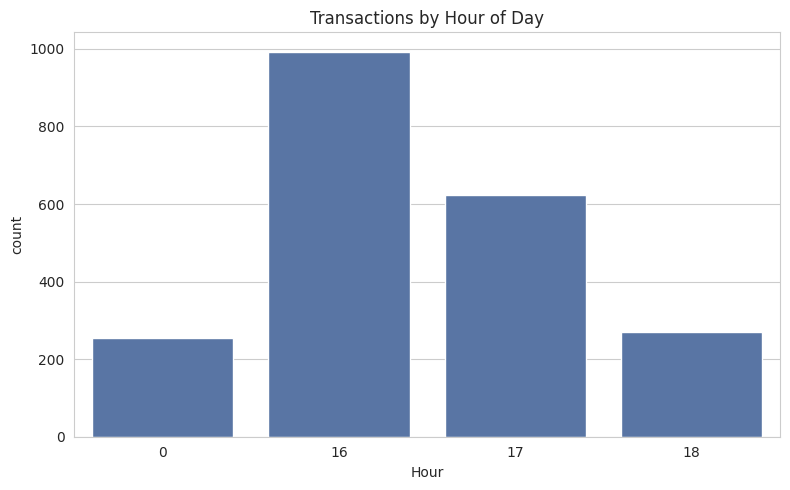

In [29]:

fig, ax = plt.subplots(figsize=(8,5))
sns.countplot(x='Hour', data=df, color='#4C72B0', ax=ax)
ax.set_title('Transactions by Hour of Day')
plt.tight_layout()
plt.show()

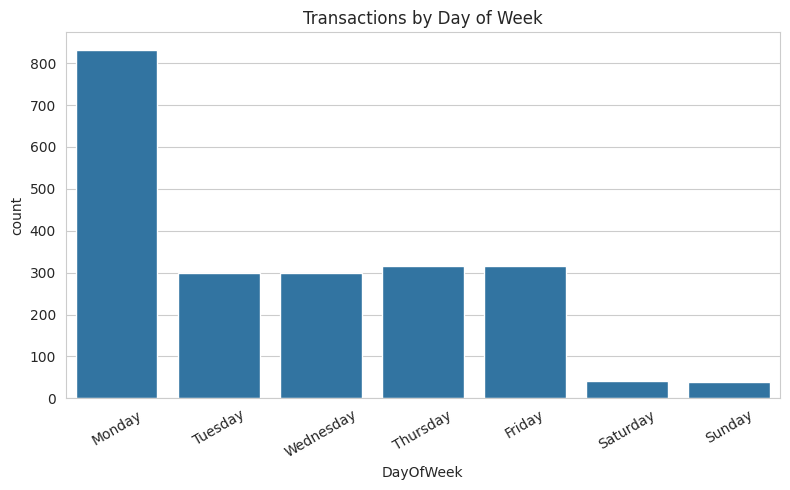

In [30]:

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
fig, ax = plt.subplots(figsize=(8,5))
sns.countplot(x='DayOfWeek', data=df, order=order, ax=ax)
ax.set_title('Transactions by Day of Week')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

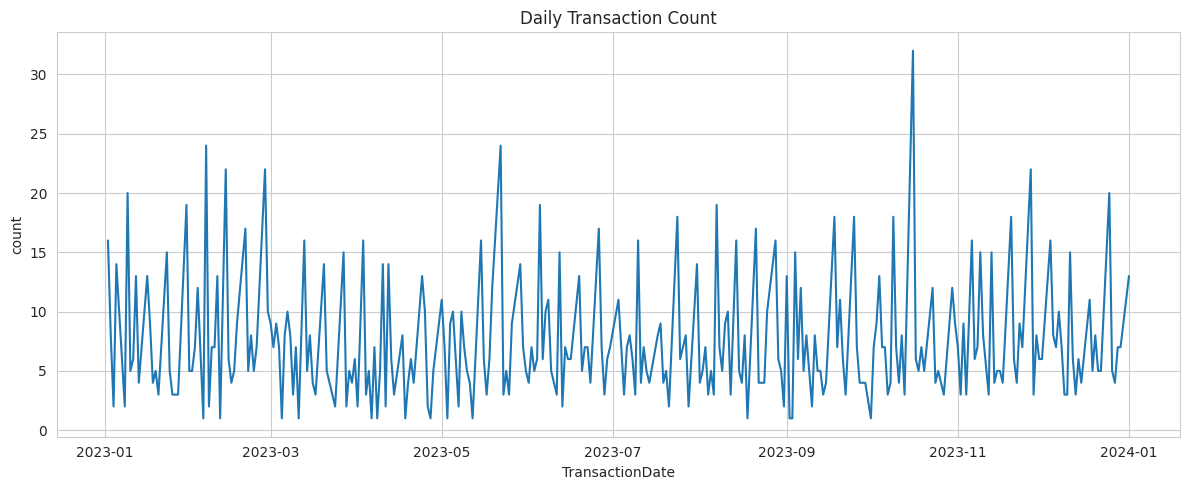

In [31]:
# daily count over the year, looking for spikes/drops
daily = df.groupby(df['TransactionDate'].dt.date).size()
fig, ax = plt.subplots(figsize=(12,5))
daily.plot(ax=ax)
ax.set_title('Daily Transaction Count')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()

## Login attempts vs transaction type
more than 3 attempts felt like a reasonable cutoff to flag as risky, not scientific but a decent starting point


In [32]:

pd.crosstab(df['TransactionType'], df['LoginAttempts'])

LoginAttempts    -3    0     1    2    3    4    5    50   99
TransactionType                                              
Credit             0    0   283    1    3    1    3    0    1
Debit              1    1  1759   21   20   26   20    1    0

In [33]:
# how many transactions had more than 3 login attempts
high_login = df[df['LoginAttempts'] > 3]
high_login.shape[0]

52

In [34]:
# eyeballing a few of these rows
high_login[['TransactionID','AccountID','TransactionAmount','LoginAttempts','Channel','TransactionType']].head(10)

    TransactionID AccountID  TransactionAmount  LoginAttempts Channel  \
21       TX000899   AC00083             919.71              4  ONLINE   
50       TX000275   AC00454             919.71              5     ATM   
135      TX000773   AC00093             827.14              4  BRANCH   
186      TX002125   AC00039             737.46              4  BRANCH   
232      TX000808   AC00316             668.67              4  ONLINE   
283      TX000455   AC00264             611.11              4     ATM   
376      TX000148   AC00161             514.95              5  ONLINE   
377      TX000148   AC00161             514.95              5  ONLINE   
393      TX000492   AC00318             505.19              5     ATM   
462      TX001885   AC00071             451.31              5     ATM   

    TransactionType  
21            Debit  
50            Debit  
135           Debit  
186           Debit  
232           Debit  
283           Debit  
376           Debit  
377          Credit 

## Summary by occupation
last check - avg spend/balance/age per occupation group


In [35]:

df.groupby('CustomerOccupation')[['TransactionAmount','AccountBalance','CustomerAge']].mean().round(2)

                    TransactionAmount  AccountBalance  CustomerAge
CustomerOccupation                                                
Doctor                         291.22         8775.02        49.44
Engineer                       276.87         5396.21        42.55
Retired                        280.52         4492.99        64.61
Student                        294.36         1719.20        26.31